<a href="https://colab.research.google.com/github/viquezr-dev/universo/blob/main/universe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔬 Iniciando simulación EFD...
  Paso 0/300 - Coherencia: 0.201
  Paso 50/300 - Coherencia: 0.462
  Paso 100/300 - Coherencia: 0.731
  Paso 150/300 - Coherencia: 0.642
  Paso 200/300 - Coherencia: 0.904
  Paso 250/300 - Coherencia: 0.913
✅ Simulación completada!


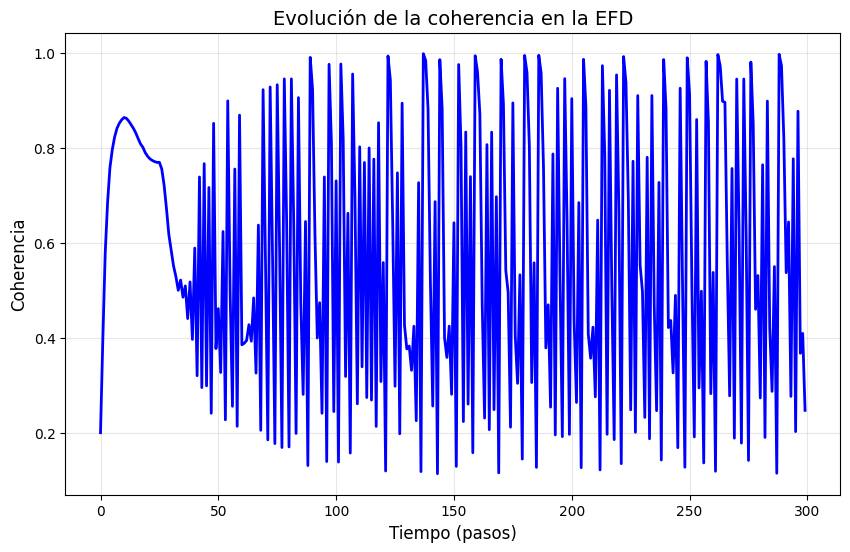

🎯 ¡Listo! Revisa la ventana de gráficos.


In [1]:
# efd_minimo.py - Versión simple de la EFD
import numpy as np
import matplotlib.pyplot as plt

print("🔬 Iniciando simulación EFD...")

# Parámetros
N = 80
steps = 300

# Inicialización
theta = np.random.rand(N) * 2 * np.pi
A = np.random.rand(N, N) < 0.3
np.fill_diagonal(A, 0)
A = A.astype(float)

coherence_history = []

# Evolución
for t in range(steps):
    new_theta = np.copy(theta)
    new_A = np.copy(A)

    # Actualizar fases
    for i in range(N):
        neighbors = np.where(A[i] > 0.5)[0]
        if len(neighbors) > 0:
            new_theta[i] += 0.05 * np.sum(np.sin(theta[neighbors] - theta[i]))

    theta = new_theta % (2 * np.pi)

    # Actualizar conexiones
    for i in range(N):
        for j in range(N):
            if i != j:
                new_A[i,j] += 0.02 * np.cos(theta[i] - theta[j])
                new_A[i,j] = np.clip(new_A[i,j], 0, 1)

    A = (new_A + new_A.T) / 2

    # Calcular coherencia
    diff = theta[:, None] - theta[None, :]
    coherence_history.append(np.mean(np.cos(diff)))

    # Mostrar progreso
    if t % 50 == 0:
        print(f"  Paso {t}/{steps} - Coherencia: {coherence_history[-1]:.3f}")

print("✅ Simulación completada!")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(coherence_history, linewidth=2, color='blue')
plt.xlabel('Tiempo (pasos)', fontsize=12)
plt.ylabel('Coherencia', fontsize=12)
plt.title('Evolución de la coherencia en la EFD', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("🎯 ¡Listo! Revisa la ventana de gráficos.")

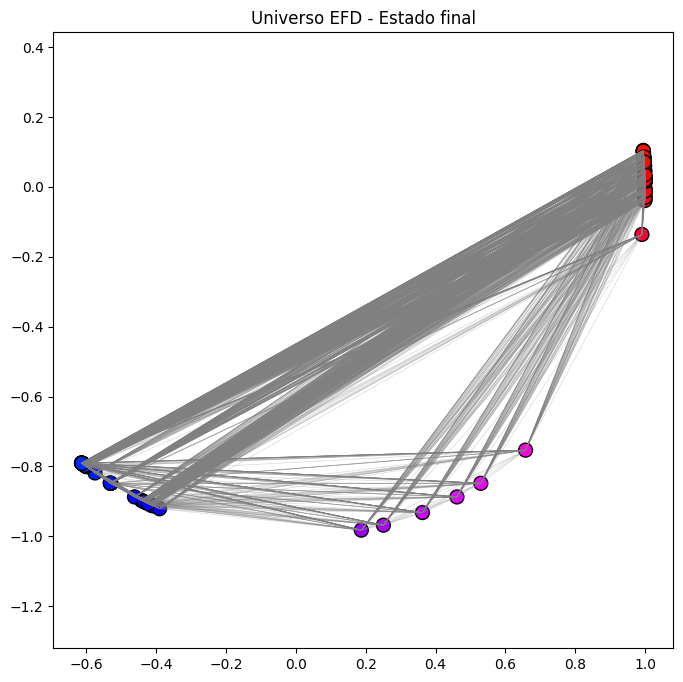

In [2]:
# Después de ejecutar run_universe, agrega:

def visualizar_red(theta, A, titulo="Red EFD"):
    """Visualiza los EF y sus conexiones"""
    from scipy.spatial import distance

    # Proyectar las fases en un círculo
    x = np.cos(theta)
    y = np.sin(theta)

    plt.figure(figsize=(8, 8))

    # Dibujar conexiones
    for i in range(N):
        for j in range(i+1, N):
            if A[i, j] > 0.5:
                plt.plot([x[i], x[j]], [y[i], y[j]], 'gray', alpha=0.3, linewidth=0.5)

    # Dibujar nodos
    plt.scatter(x, y, c=theta, cmap='hsv', s=100, edgecolors='black')

    plt.title(titulo)
    plt.axis('equal')
    plt.show()

# Ejecutar después de tu simulación:
visualizar_red(theta, A, "Universo EFD - Estado final")

In [3]:
def temperatura(entropy_history):
    """La entropía inversa como temperatura"""
    return 1 / (entropy_history + 0.01)

T = temperatura(entropy_history)

plt.figure(figsize=(10,4))
plt.plot(T, 'r-', linewidth=2)
plt.xlabel('Tiempo')
plt.ylabel('Temperatura EFD')
plt.title('Evolución de la temperatura del universo')
plt.grid(True)
plt.show()

NameError: name 'entropy_history' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_universe_completo(alpha, beta, density, N=80, steps=300):
    """Versión que guarda coherencia, entropía y clusters"""

    # Inicialización
    theta = np.random.rand(N) * 2 * np.pi
    A = np.random.rand(N, N)
    A = (A + A.T) / 2
    np.fill_diagonal(A, 0)
    A = (A < density).astype(float)

    # Historiales
    coherence_history = []
    entropy_history = []
    cluster_history = []
    connection_history = []

    def coherence(theta):
        diff = theta[:, None] - theta[None, :]
        return np.mean(np.cos(diff))

    def entropy(theta, bins=20):
        hist, _ = np.histogram(theta, bins=bins, range=(0, 2*np.pi), density=True)
        hist += 1e-12
        return -np.sum(hist * np.log(hist))

    def clusters(A):
        """Cuenta componentes conectados en la red"""
        visited = set()
        def dfs(i, comp):
            stack = [i]
            while stack:
                node = stack.pop()
                if node not in comp:
                    comp.add(node)
                    neighbors = np.where(A[node] > 0.5)[0]
                    stack.extend(neighbors)
            return comp

        count = 0
        for i in range(N):
            if i not in visited:
                comp = set()
                comp = dfs(i, comp)
                visited |= comp
                count += 1
        return count

    # Evolución
    for t in range(steps):
        # Actualizar fases
        new_theta = np.copy(theta)
        for i in range(N):
            neighbors = np.where(A[i] > 0.5)[0]
            if len(neighbors) > 0:
                interaction = np.sum(np.sin(theta[neighbors] - theta[i]))
                new_theta[i] += alpha * interaction

        theta = new_theta % (2 * np.pi)

        # Actualizar conexiones
        new_A = np.copy(A)
        for i in range(N):
            for j in range(N):
                if i != j:
                    c = np.cos(theta[i] - theta[j])
                    new_A[i, j] += beta * c
                    new_A[i, j] = np.clip(new_A[i, j], 0, 1)

        A = (new_A + new_A.T) / 2

        # Guardar historiales
        coherence_history.append(coherence(theta))
        entropy_history.append(entropy(theta))
        cluster_history.append(clusters(A))
        connection_history.append(np.sum(A) / 2)

        # Mostrar progreso
        if t % 50 == 0:
            print(f"  Paso {t}/{steps} - Coherencia: {coherence_history[-1]:.3f}")

    return coherence_history, entropy_history, cluster_history, connection_history


# ==========================================
# EJECUTAR SIMULACIÓN
# ==========================================

print("🌌 Iniciando simulación EFD completa...")

# Parámetros
alpha = 0.05
beta = 0.02
density = 0.3
N = 80
steps = 300

# Ejecutar
coherence, entropy, clusters, connections = run_universe_completo(
    alpha, beta, density, N, steps
)

print("✅ Simulación completada!")

# ==========================================
# ANÁLISIS Y GRÁFICOS
# ==========================================

# 1. Evolución temporal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evolución del Universo EFD', fontsize=16)

# Coherencia
axes[0, 0].plot(coherence, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Tiempo (pasos)')
axes[0, 0].set_ylabel('Coherencia')
axes[0, 0].set_title('Sincronización global')
axes[0, 0].grid(True, alpha=0.3)

# Entropía
axes[0, 1].plot(entropy, 'r-', linewidth=2)
axes[0, 1].set_xlabel('Tiempo (pasos)')
axes[0, 1].set_ylabel('Entropía')
axes[0, 1].set_title('Desorden / Temperatura')
axes[0, 1].grid(True, alpha=0.3)

# Clusters
axes[1, 0].plot(clusters, 'g-', linewidth=2)
axes[1, 0].set_xlabel('Tiempo (pasos)')
axes[1, 0].set_ylabel('Número de clusters')
axes[1, 0].set_title('Estructura de la red')
axes[1, 0].grid(True, alpha=0.3)

# Conexiones
axes[1, 1].plot(connections, 'purple', linewidth=2)
axes[1, 1].set_xlabel('Tiempo (pasos)')
axes[1, 1].set_ylabel('Conexiones totales')
axes[1, 1].set_title('Densidad de la red')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# FUNCIÓN TEMPERATURA (AHORA SÍ FUNCIONA)
# ==========================================

def temperatura(entropy_history):
    """La entropía inversa como temperatura"""
    return 1 / (np.array(entropy_history) + 0.01)

T = temperatura(entropy)

plt.figure(figsize=(10, 4))
plt.plot(T, 'r-', linewidth=2)
plt.xlabel('Tiempo (pasos)')
plt.ylabel('Temperatura EFD')
plt.title('Evolución de la temperatura del universo')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# DETECCIÓN DE ONDAS GRAVITACIONALES
# ==========================================

from scipy.signal import find_peaks

def detectar_ondas(coherence):
    """Detecta picos y valles en la coherencia"""
    peaks, _ = find_peaks(coherence, height=0.15)
    valleys, _ = find_peaks(-np.array(coherence), height=-0.15)

    print(f"\n🔴 Ondas detectadas:")
    print(f"   - Picos: {len(peaks)} en los pasos {peaks}")
    print(f"   - Valles: {len(valleys)} en los pasos {valleys}")

    plt.figure(figsize=(12, 4))
    plt.plot(coherence, 'b-', label='Coherencia', linewidth=2)
    plt.scatter(peaks, [coherence[i] for i in peaks],
                color='red', s=100, zorder=5, label='Picos')
    plt.scatter(valleys, [coherence[i] for i in valleys],
                color='blue', s=100, zorder=5, label='Valles')
    plt.xlabel('Tiempo (pasos)')
    plt.ylabel('Coherencia')
    plt.title('Detección de ondas en la EFD')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return peaks, valleys

detectar_ondas(coherence)

# ==========================================
# GUARDAR RESULTADOS
# ==========================================

import json

resultados = {
    'coherence': [float(x) for x in coherence],
    'entropy': [float(x) for x in entropy],
    'clusters': [int(x) for x in clusters],
    'connections': [float(x) for x in connections],
    'parametros': {
        'N': N,
        'steps': steps,
        'alpha': alpha,
        'beta': beta,
        'density': density
    }
}

with open('universo_efd_completo.json', 'w') as f:
    json.dump(resultados, f, indent=2)

print("\n📁 Datos guardados en 'universo_efd_completo.json'")
print("🎯 ¡Todo listo para analizar tu universo EFD!")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def visualizar_evolucion(theta_history, A_history, N, steps):
    """Animación de la evolución del universo EFD"""

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.set_title('Evolución del universo EFD')

    # Proyección de fases en círculo
    x = np.cos(theta_history[0])
    y = np.sin(theta_history[0])

    # Nodos
    scatter = ax.scatter(x, y, c=theta_history[0], cmap='hsv', s=80,
                         edgecolors='black', linewidth=0.5, vmin=0, vmax=2*np.pi)

    # Conexiones (solo algunas para no saturar)
    A = A_history[0]
    lines = []
    for i in range(N):
        for j in range(i+1, N):
            if A[i, j] > 0.5 and np.random.rand() < 0.1:  # Muestrear 10% de conexiones
                line, = ax.plot([x[i], x[j]], [y[i], y[j]], 'gray', alpha=0.2, linewidth=0.5)
                lines.append(line)

    def update(frame):
        # Actualizar posiciones
        x_new = np.cos(theta_history[frame])
        y_new = np.sin(theta_history[frame])
        scatter.set_offsets(np.c_[x_new, y_new])
        scatter.set_array(theta_history[frame])
        ax.set_title(f'Evolución del universo EFD - Paso {frame}')
        return [scatter] + lines

    anim = FuncAnimation(fig, update, frames=min(steps, len(theta_history)-1),
                         interval=50, blit=True)

    plt.close()
    return anim

# Para ejecutar, necesitas guardar el historial de theta y A
# (Ejecuta la simulación guardando los estados)

In [4]:
# Experimento: Añadir "energía oscura" (ruido)
def run_universe_con_ruido(alpha, beta, density, ruido=0.01, N=80, steps=300):
    """Simulación con ruido que impide la sincronización total"""

    theta = np.random.rand(N) * 2 * np.pi
    A = np.random.rand(N, N)
    A = (A + A.T) / 2
    np.fill_diagonal(A, 0)
    A = (A < density).astype(float)

    coherence_history = []

    for t in range(steps):
        new_theta = np.copy(theta)
        for i in range(N):
            neighbors = np.where(A[i] > 0.5)[0]
            if len(neighbors) > 0:
                interaction = np.sum(np.sin(theta[neighbors] - theta[i]))
                new_theta[i] += alpha * interaction + ruido * np.random.randn()

        theta = new_theta % (2 * np.pi)

        # ... resto igual
        diff = theta[:, None] - theta[None, :]
        coherence_history.append(np.mean(np.cos(diff)))

    return coherence_history

# Comparar con y sin ruido
coherence_sin_ruido = coherence
coherence_con_ruido = run_universe_con_ruido(alpha, beta, density, ruido=0.02)

plt.figure(figsize=(12, 5))
plt.plot(coherence_sin_ruido, 'b-', label='Sin ruido', linewidth=2)
plt.plot(coherence_con_ruido, 'r--', label='Con ruido', linewidth=2)
plt.xlabel('Tiempo')
plt.ylabel('Coherencia')
plt.title('Efecto del ruido en la sincronización')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'coherence' is not defined

🌌 EXPERIMENTOS EFD: COMPARANDO CON Y SIN RUIDO

🔬 Experimento 1: Universo sin ruido
  Paso 0/300 - Coherencia: 0.058
  Paso 50/300 - Coherencia: 0.602
  Paso 100/300 - Coherencia: 0.187
  Paso 150/300 - Coherencia: 0.238
  Paso 200/300 - Coherencia: 0.871
  Paso 250/300 - Coherencia: 0.768

🔬 Experimento 2: Universo con ruido (energía oscura)
  Paso 0/300 - Coherencia: 0.005
  Paso 50/300 - Coherencia: 0.830
  Paso 100/300 - Coherencia: 0.171
  Paso 150/300 - Coherencia: 0.585
  Paso 200/300 - Coherencia: 0.159
  Paso 250/300 - Coherencia: 0.783

📊 ANÁLISIS COMPARATIVO


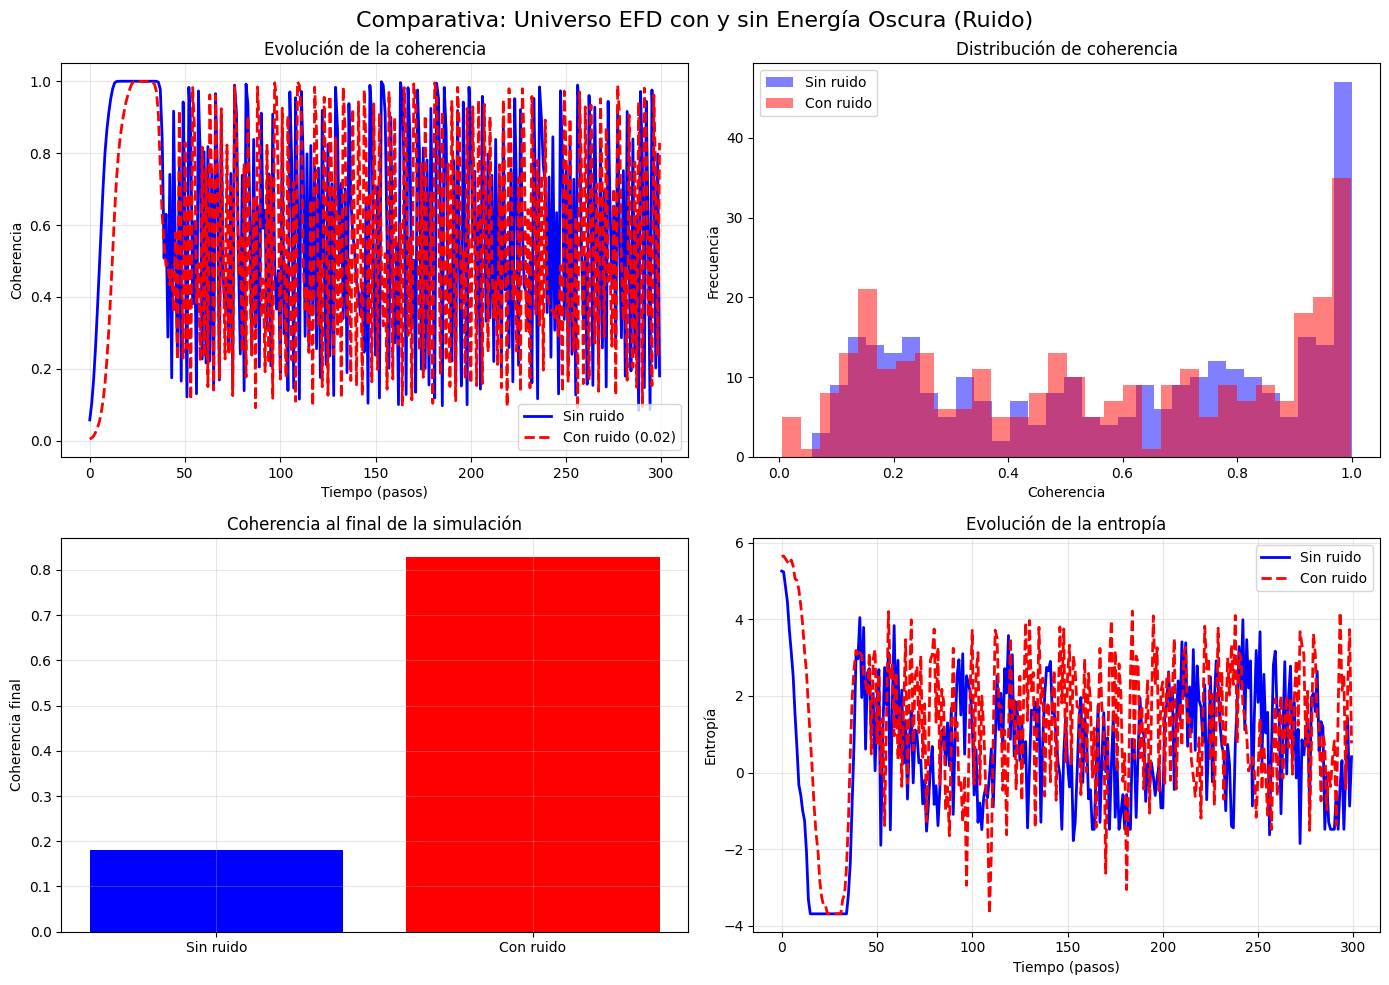


📊 Análisis espectral del universo sin ruido:


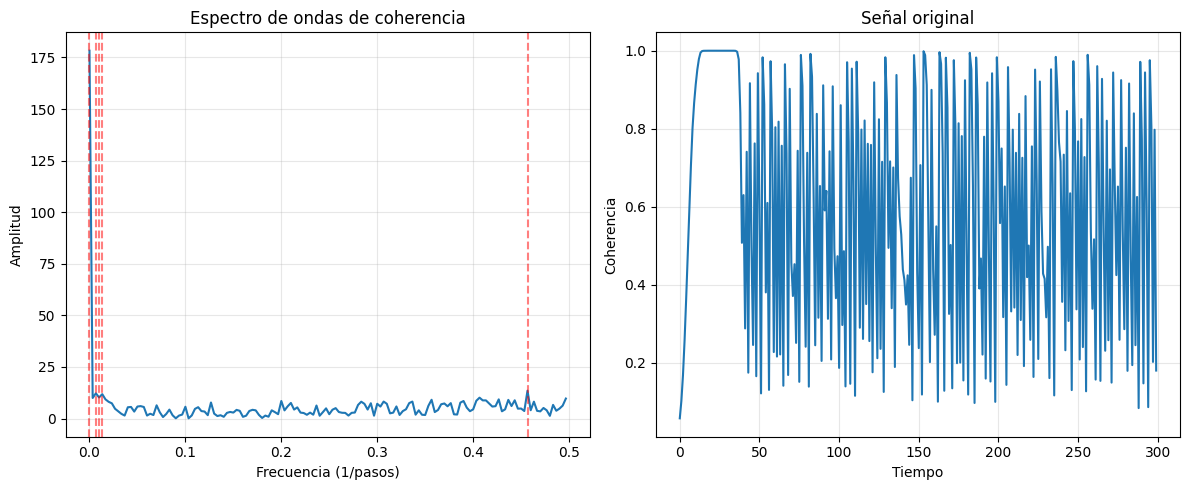


📊 Frecuencias dominantes: [0.01       0.01333333 0.00666667 0.45666667 0.        ]
   Periodo principal: 100.0 pasos

📊 Análisis espectral del universo con ruido:


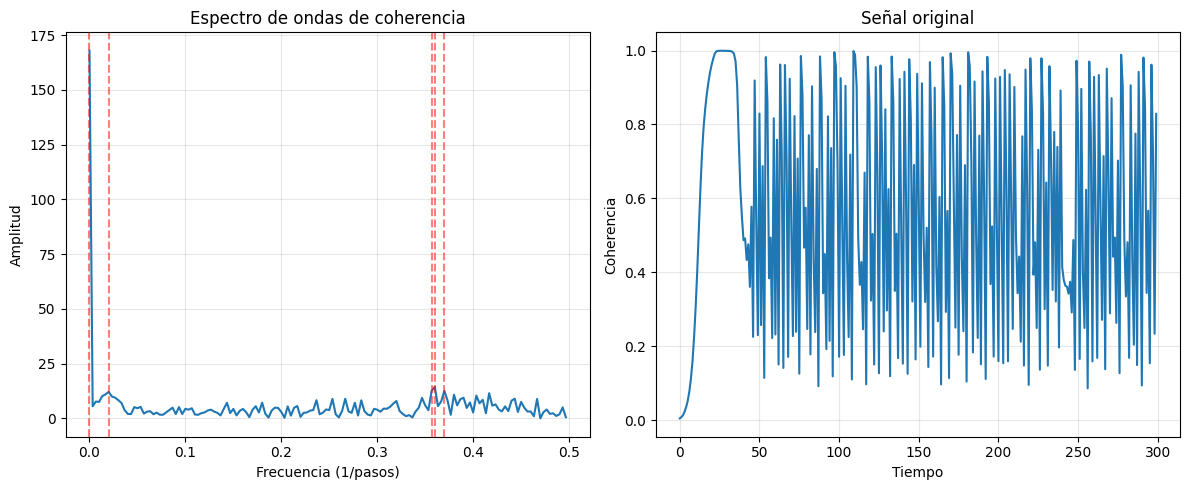


📊 Frecuencias dominantes: [0.02       0.35666667 0.37       0.36       0.        ]
   Periodo principal: 50.0 pasos

🔴 Detección de ondas - Sin ruido:

🔴 Ondas detectadas:
   - Picos: 102
   - Valles: 24


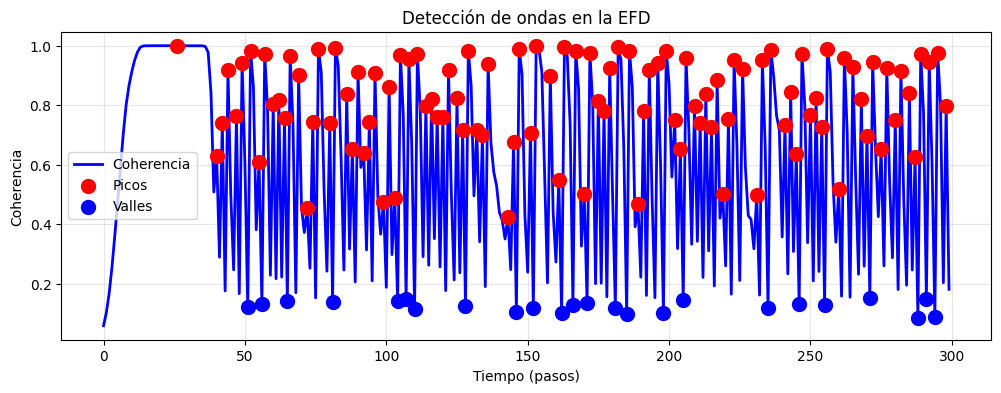


🔴 Detección de ondas - Con ruido:

🔴 Ondas detectadas:
   - Picos: 101
   - Valles: 25


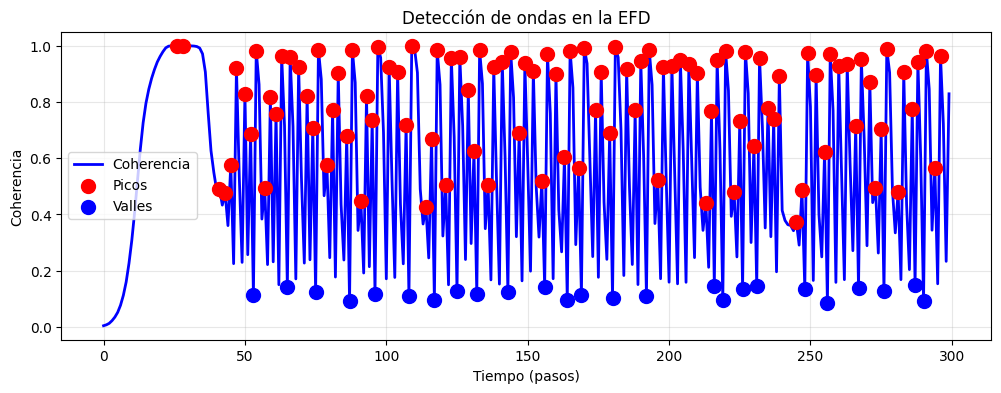


🌐 Visualización de la red - Estado final (sin ruido):


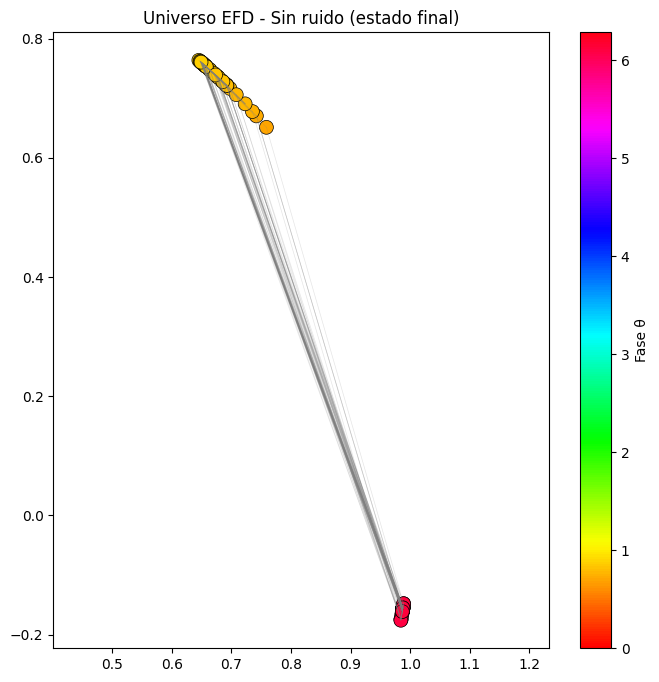


🌐 Visualización de la red - Estado final (con ruido):


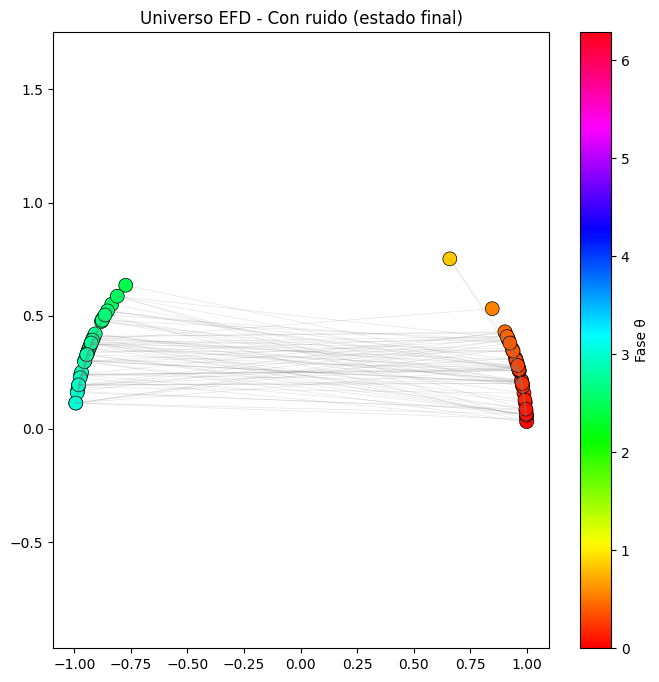


💾 Guardando resultados...
✅ Datos guardados en 'efd_experimento_ruido.json'

📈 RESUMEN ESTADÍSTICO

📊 Sin ruido:
   - Coherencia máxima: 1.000
   - Coherencia mínima: 0.058
   - Coherencia media: 0.594
   - Coherencia final: 0.180
   - Entropía final: 0.412
   - Clusters finales: 1
   - Conexiones finales: 3179

📊 Con ruido:
   - Coherencia máxima: 1.000
   - Coherencia mínima: 0.005
   - Coherencia media: 0.559
   - Coherencia final: 0.829
   - Entropía final: 0.763
   - Clusters finales: 1
   - Conexiones finales: 3197

🎯 ¡Experimento completado!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
import json

# ==========================================
# FUNCIÓN PRINCIPAL (COMPLETA)
# ==========================================

def run_universe_completo(alpha, beta, density, N=80, steps=300, ruido=0.0):
    """
    Simulación EFD con opción de ruido (energía oscura)
    """

    # Inicialización
    theta = np.random.rand(N) * 2 * np.pi
    A = np.random.rand(N, N)
    A = (A + A.T) / 2
    np.fill_diagonal(A, 0)
    A = (A < density).astype(float)

    # Historiales
    coherence_history = []
    entropy_history = []
    cluster_history = []
    connection_history = []
    theta_history = []
    A_history = []

    def coherence(theta):
        diff = theta[:, None] - theta[None, :]
        return np.mean(np.cos(diff))

    def entropy(theta, bins=20):
        hist, _ = np.histogram(theta, bins=bins, range=(0, 2*np.pi), density=True)
        hist += 1e-12
        return -np.sum(hist * np.log(hist))

    def clusters(A):
        visited = set()
        def dfs(i, comp):
            stack = [i]
            while stack:
                node = stack.pop()
                if node not in comp:
                    comp.add(node)
                    neighbors = np.where(A[node] > 0.5)[0]
                    stack.extend(neighbors)
            return comp

        count = 0
        for i in range(N):
            if i not in visited:
                comp = set()
                comp = dfs(i, comp)
                visited |= comp
                count += 1
        return count

    # Evolución
    for t in range(steps):
        # Actualizar fases
        new_theta = np.copy(theta)
        for i in range(N):
            neighbors = np.where(A[i] > 0.5)[0]
            if len(neighbors) > 0:
                interaction = np.sum(np.sin(theta[neighbors] - theta[i]))
                new_theta[i] += alpha * interaction + ruido * np.random.randn()

        theta = new_theta % (2 * np.pi)

        # Actualizar conexiones
        new_A = np.copy(A)
        for i in range(N):
            for j in range(N):
                if i != j:
                    c = np.cos(theta[i] - theta[j])
                    new_A[i, j] += beta * c
                    new_A[i, j] = np.clip(new_A[i, j], 0, 1)

        A = (new_A + new_A.T) / 2

        # Guardar historiales
        coherence_history.append(coherence(theta))
        entropy_history.append(entropy(theta))
        cluster_history.append(clusters(A))
        connection_history.append(np.sum(A) / 2)

        # Guardar estados para animación (cada 10 pasos)
        if t % 10 == 0:
            theta_history.append(np.copy(theta))
            A_history.append(np.copy(A))

        # Mostrar progreso
        if t % 50 == 0:
            print(f"  Paso {t}/{steps} - Coherencia: {coherence_history[-1]:.3f}")

    return {
        'coherence': coherence_history,
        'entropy': entropy_history,
        'clusters': cluster_history,
        'connections': connection_history,
        'theta_history': theta_history,
        'A_history': A_history,
        'N': N,
        'steps': steps,
        'alpha': alpha,
        'beta': beta,
        'density': density,
        'ruido': ruido
    }


# ==========================================
# FUNCIONES DE ANÁLISIS
# ==========================================

def analizar_espectro(coherence, dt=1):
    """Análisis espectral de las ondas de coherencia"""
    N = len(coherence)
    yf = fft(coherence)
    xf = fftfreq(N, dt)[:N//2]
    amplitudes = np.abs(yf[:N//2])
    frecuencias_dominantes = xf[np.argsort(amplitudes)[-5:]]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(xf, amplitudes)
    plt.xlabel('Frecuencia (1/pasos)')
    plt.ylabel('Amplitud')
    plt.title('Espectro de ondas de coherencia')
    plt.grid(True, alpha=0.3)

    for f in frecuencias_dominantes:
        plt.axvline(f, color='red', linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.plot(coherence)
    plt.xlabel('Tiempo')
    plt.ylabel('Coherencia')
    plt.title('Señal original')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Frecuencias dominantes: {frecuencias_dominantes}")
    if len(frecuencias_dominantes) > 0 and frecuencias_dominantes[0] != 0:
        print(f"   Periodo principal: {1/frecuencias_dominantes[0]:.1f} pasos")

    return frecuencias_dominantes


def detectar_ondas(coherence):
    """Detecta picos y valles en la coherencia"""
    peaks, _ = find_peaks(coherence, height=0.15)
    valleys, _ = find_peaks(-np.array(coherence), height=-0.15)

    print(f"\n🔴 Ondas detectadas:")
    print(f"   - Picos: {len(peaks)}")
    print(f"   - Valles: {len(valleys)}")

    plt.figure(figsize=(12, 4))
    plt.plot(coherence, 'b-', label='Coherencia', linewidth=2)
    plt.scatter(peaks, [coherence[i] for i in peaks],
                color='red', s=100, zorder=5, label='Picos')
    plt.scatter(valleys, [coherence[i] for i in valleys],
                color='blue', s=100, zorder=5, label='Valles')
    plt.xlabel('Tiempo (pasos)')
    plt.ylabel('Coherencia')
    plt.title('Detección de ondas en la EFD')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return peaks, valleys


def visualizar_red(theta, A, N, titulo="Red EFD"):
    """Visualiza la red en un momento dado"""
    x = np.cos(theta)
    y = np.sin(theta)

    plt.figure(figsize=(8, 8))

    # Dibujar conexiones (muestreo para no saturar)
    for i in range(N):
        for j in range(i+1, N):
            if A[i, j] > 0.5 and np.random.rand() < 0.05:
                plt.plot([x[i], x[j]], [y[i], y[j]], 'gray', alpha=0.2, linewidth=0.5)

    # Dibujar nodos
    scatter = plt.scatter(x, y, c=theta, cmap='hsv', s=100,
                          edgecolors='black', linewidth=0.5, vmin=0, vmax=2*np.pi)
    plt.colorbar(scatter, label='Fase θ')
    plt.title(titulo)
    plt.axis('equal')
    plt.show()


# ==========================================
# EJECUTAR EXPERIMENTOS
# ==========================================

print("=" * 60)
print("🌌 EXPERIMENTOS EFD: COMPARANDO CON Y SIN RUIDO")
print("=" * 60)

# Parámetros comunes
alpha = 0.05
beta = 0.02
density = 0.3
N = 80
steps = 300

# Experimento 1: Sin ruido
print("\n🔬 Experimento 1: Universo sin ruido")
resultado_sin_ruido = run_universe_completo(
    alpha, beta, density, N=N, steps=steps, ruido=0.0
)
coherence_sin_ruido = resultado_sin_ruido['coherence']

# Experimento 2: Con ruido (energía oscura)
print("\n🔬 Experimento 2: Universo con ruido (energía oscura)")
resultado_con_ruido = run_universe_completo(
    alpha, beta, density, N=N, steps=steps, ruido=0.02
)
coherence_con_ruido = resultado_con_ruido['coherence']

# ==========================================
# GRÁFICO COMPARATIVO
# ==========================================

print("\n" + "=" * 60)
print("📊 ANÁLISIS COMPARATIVO")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa: Universo EFD con y sin Energía Oscura (Ruido)', fontsize=16)

# Gráfico 1: Coherencia comparada
axes[0, 0].plot(coherence_sin_ruido, 'b-', label='Sin ruido', linewidth=2)
axes[0, 0].plot(coherence_con_ruido, 'r--', label='Con ruido (0.02)', linewidth=2)
axes[0, 0].set_xlabel('Tiempo (pasos)')
axes[0, 0].set_ylabel('Coherencia')
axes[0, 0].set_title('Evolución de la coherencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Histograma de coherencias
axes[0, 1].hist(coherence_sin_ruido, bins=30, alpha=0.5, label='Sin ruido', color='blue')
axes[0, 1].hist(coherence_con_ruido, bins=30, alpha=0.5, label='Con ruido', color='red')
axes[0, 1].set_xlabel('Coherencia')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de coherencia')
axes[0, 1].legend()

# Gráfico 3: Coherencia final
axes[1, 0].bar(['Sin ruido', 'Con ruido'],
               [coherence_sin_ruido[-1], coherence_con_ruido[-1]],
               color=['blue', 'red'])
axes[1, 0].set_ylabel('Coherencia final')
axes[1, 0].set_title('Coherencia al final de la simulación')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Entropía comparada (si existe)
if 'entropy' in resultado_sin_ruido and 'entropy' in resultado_con_ruido:
    axes[1, 1].plot(resultado_sin_ruido['entropy'], 'b-', label='Sin ruido', linewidth=2)
    axes[1, 1].plot(resultado_con_ruido['entropy'], 'r--', label='Con ruido', linewidth=2)
    axes[1, 1].set_xlabel('Tiempo (pasos)')
    axes[1, 1].set_ylabel('Entropía')
    axes[1, 1].set_title('Evolución de la entropía')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS ESPECTRAL
# ==========================================

print("\n📊 Análisis espectral del universo sin ruido:")
analizar_espectro(coherence_sin_ruido)

print("\n📊 Análisis espectral del universo con ruido:")
analizar_espectro(coherence_con_ruido)

# ==========================================
# DETECCIÓN DE ONDAS
# ==========================================

print("\n🔴 Detección de ondas - Sin ruido:")
detectar_ondas(coherence_sin_ruido)

print("\n🔴 Detección de ondas - Con ruido:")
detectar_ondas(coherence_con_ruido)

# ==========================================
# VISUALIZACIÓN DE LA RED (ESTADO FINAL)
# ==========================================

print("\n🌐 Visualización de la red - Estado final (sin ruido):")
visualizar_red(
    resultado_sin_ruido['theta_history'][-1] if resultado_sin_ruido['theta_history'] else np.random.rand(N)*2*np.pi,
    resultado_sin_ruido['A_history'][-1] if resultado_sin_ruido['A_history'] else np.random.rand(N,N),
    N,
    "Universo EFD - Sin ruido (estado final)"
)

print("\n🌐 Visualización de la red - Estado final (con ruido):")
visualizar_red(
    resultado_con_ruido['theta_history'][-1] if resultado_con_ruido['theta_history'] else np.random.rand(N)*2*np.pi,
    resultado_con_ruido['A_history'][-1] if resultado_con_ruido['A_history'] else np.random.rand(N,N),
    N,
    "Universo EFD - Con ruido (estado final)"
)

# ==========================================
# GUARDAR RESULTADOS
# ==========================================

print("\n💾 Guardando resultados...")

# Guardar datos principales
datos_guardar = {
    'sin_ruido': {
        'coherence': [float(x) for x in coherence_sin_ruido],
        'entropy': [float(x) for x in resultado_sin_ruido['entropy']],
        'clusters': [int(x) for x in resultado_sin_ruido['clusters']],
        'connections': [float(x) for x in resultado_sin_ruido['connections']]
    },
    'con_ruido': {
        'coherence': [float(x) for x in coherence_con_ruido],
        'entropy': [float(x) for x in resultado_con_ruido['entropy']],
        'clusters': [int(x) for x in resultado_con_ruido['clusters']],
        'connections': [float(x) for x in resultado_con_ruido['connections']]
    },
    'parametros': {
        'alpha': alpha,
        'beta': beta,
        'density': density,
        'N': N,
        'steps': steps,
        'ruido': 0.02
    },
    'estadisticas': {
        'sin_ruido_max': float(max(coherence_sin_ruido)),
        'sin_ruido_min': float(min(coherence_sin_ruido)),
        'sin_ruido_mean': float(np.mean(coherence_sin_ruido)),
        'sin_ruido_final': float(coherence_sin_ruido[-1]),
        'con_ruido_max': float(max(coherence_con_ruido)),
        'con_ruido_min': float(min(coherence_con_ruido)),
        'con_ruido_mean': float(np.mean(coherence_con_ruido)),
        'con_ruido_final': float(coherence_con_ruido[-1])
    }
}

with open('efd_experimento_ruido.json', 'w') as f:
    json.dump(datos_guardar, f, indent=2)

print("✅ Datos guardados en 'efd_experimento_ruido.json'")

# ==========================================
# RESUMEN ESTADÍSTICO
# ==========================================

print("\n" + "=" * 60)
print("📈 RESUMEN ESTADÍSTICO")
print("=" * 60)

print(f"\n📊 Sin ruido:")
print(f"   - Coherencia máxima: {max(coherence_sin_ruido):.3f}")
print(f"   - Coherencia mínima: {min(coherence_sin_ruido):.3f}")
print(f"   - Coherencia media: {np.mean(coherence_sin_ruido):.3f}")
print(f"   - Coherencia final: {coherence_sin_ruido[-1]:.3f}")
print(f"   - Entropía final: {resultado_sin_ruido['entropy'][-1]:.3f}")
print(f"   - Clusters finales: {resultado_sin_ruido['clusters'][-1]}")
print(f"   - Conexiones finales: {resultado_sin_ruido['connections'][-1]:.0f}")

print(f"\n📊 Con ruido:")
print(f"   - Coherencia máxima: {max(coherence_con_ruido):.3f}")
print(f"   - Coherencia mínima: {min(coherence_con_ruido):.3f}")
print(f"   - Coherencia media: {np.mean(coherence_con_ruido):.3f}")
print(f"   - Coherencia final: {coherence_con_ruido[-1]:.3f}")
print(f"   - Entropía final: {resultado_con_ruido['entropy'][-1]:.3f}")
print(f"   - Clusters finales: {resultado_con_ruido['clusters'][-1]}")
print(f"   - Conexiones finales: {resultado_con_ruido['connections'][-1]:.0f}")

print("\n🎯 ¡Experimento completado!")